In [2]:
# Lecture 1
# import packages
from scipy.stats import binom
from scipy.stats import poisson
from scipy.stats import norm
from scipy.stats import chi2
from scipy.optimize import root_scalar
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
# os.chdir(r'C:\Users\Linda\Desktop\ST5213py')
pd.set_option("display.width", 2000)

# fig_save_dir = r"C:/Users/Linda/OneDrive - National University of Singapore/ST5213 2627/Lectures/Lecture_1/figure"

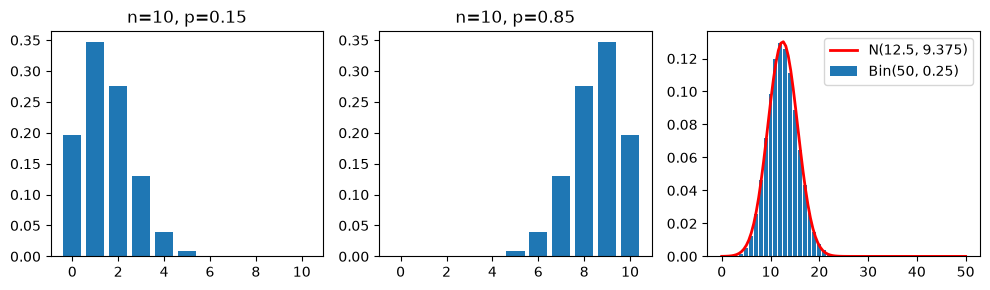

In [3]:
# Binomial distribution

# Bin(10, 0.15)
n1 = 10
p11 = 0.15
y1 = range(n1 + 1)
prob1 = binom.pmf(y1, n1, p11)

# Bin(10, 0.85), only change the success probability
p12 = 0.85
prob2 = binom.pmf(y1, n1, p12)

# Bin(50, 0.25)
n2 = 50
p2 = 0.25
y2 = range(n2 + 1)
prob3 = binom.pmf(y2, n2, p2)

# Approx Bin(50, 0.25) by normal distribution
y2_cont = np.linspace(0, n2, 100)
norm_values = norm.pdf(y2_cont, loc=n2*p2, scale=np.sqrt(n2*p2*(1-p2)))

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 3))

axes[0].bar(list(y1), prob1)
axes[0].set_title(f'n={n1}, p={p11}')

axes[1].bar(list(y1), prob2)
axes[1].set_title(f'n={n1}, p={p12}')

axes[2].bar(list(y2), prob3, label=f'Bin({n2}, {p2})')
axes[2].plot(y2_cont, norm_values, 'r-', lw=2, label=f'N({n2*p2}, {n2*p2*(1-p2)})')

plt.legend()
plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "binom.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  

plt.show()  # show AFTER saving

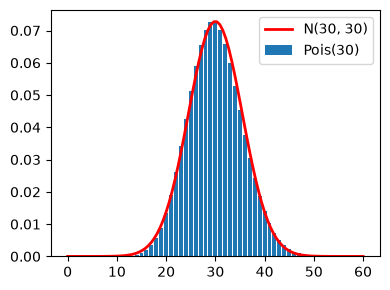

In [4]:
# Poisson distribution approximated by normal distribution
# Plot Poisson distn
mu = 30
y_values = range(60+1) 
p_values = poisson.pmf(y_values, mu)

plt.figure(figsize=(4, 3))
plt.bar(list(y_values), p_values, label=f'Pois({mu})') 

# Add normal curve
y_cont = np.linspace(0, 60, 100)
norm_values = norm.pdf(y_cont, loc=mu, scale=np.sqrt(mu))
plt.plot(y_cont, norm_values, 'r-', lw=2, label=f'N({mu}, {mu})')
# r-: set color to red and line style to solid line

plt.legend()
plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "poisson.pdf")
# plt.savefig(fig_path, bbox_inches="tight")  

plt.show()

In [5]:
# Compute p-values from chisq distn for hypothesis tests
# sf: survival function (also defined as 1 - cdf, but sf is sometimes more accurate)

print(chi2.sf(17.8, df=1))

print(chi2.sf(6.4, df=1))

print(chi2.sf(7.36, df=1))

2.453832435275804e-05
0.01141203638600166
0.006669079168301862


In [6]:
# Confidence intervals
y = 9
n = 10
phat = y/n
X2 = chi2.ppf(0.95,1)  # ppf: Percent point function (inverse of cdf)
print(f'{X2=}')

# Wald CI:
Wald_CI = phat + np.array([-1, 1]) * 1.96 * np.sqrt(phat * (1 - phat) / n)
print(f'{Wald_CI=}')

X2=np.float64(3.841458820694124)
Wald_CI=array([0.71405807, 1.08594193])


Score_CI=array([0.59584997, 0.98212379])


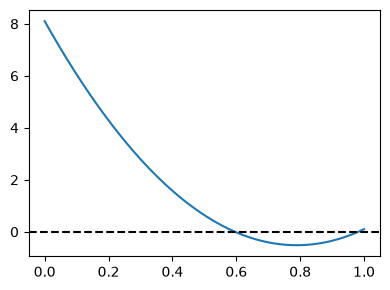

In [7]:
# Score CI:
a = n + X2
b = - (X2 + 2*y)
c = y**2 / n
Score_CI = (-b + np.array([-1, 1]) * np.sqrt(b**2 - 4*a*c)) / (2*a)
print(f'{Score_CI=}')

def f(p):
    return a * p**2 + b * p + c

p_values = np.linspace(0, 1, 100)
plt.figure(figsize=(4, 3))
plt.plot(p_values, f(p_values))
plt.axhline(0, color='black', linestyle='--',)
plt.tight_layout()
plt.show()

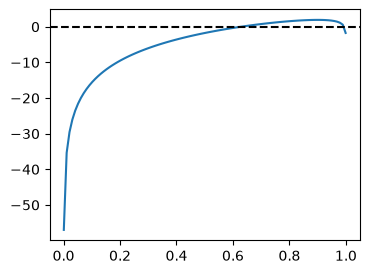

LR_CI=[0.628364190631709, 0.9940088799325342]


In [8]:
# Likelihood ratio CI
C = y * np.log(phat) + (n-y) * np.log(1-phat) - X2/2

def g(p):
    return y * np.log(p) + (n-y) * np.log(1-p) - C

p_values = np.linspace(0.001, 0.999, 100)
plt.figure(figsize=(4, 3))
plt.plot(p_values, g(p_values))
plt.axhline(0, color='black', linestyle='--',)

# fig_path = os.path.join(fig_save_dir, "likelihoodratioCI.pdf")
# plt.savefig(fig_path, bbox_inches="tight")  

plt.show()

result1 = root_scalar(g, bracket=[0.4, 0.8], method='brentq')     # left limit 
result2 = root_scalar(g, bracket=[0.8, 0.999], method='brentq')   # right limit
LR_CI = [result1.root, result2.root]
print(f'{LR_CI=}')

In [10]:
# Exploratory analysis
df = pd.read_csv('dataset/gavote.txt', sep=' ')
print(df.head(6))   # return headers and specified number of rows

          equip    econ  perAA  rural     atlanta  gore  bush  other  votes  ballots
APPLING   LEVER    poor  0.182  rural  notAtlanta  2093  3940     66   6099     6617
ATKINSON  LEVER    poor  0.230  rural  notAtlanta   821  1228     22   2071     2149
BACON     LEVER    poor  0.131  rural  notAtlanta   956  2010     29   2995     3347
BAKER     OS-CC    poor  0.476  rural  notAtlanta   893   615     11   1519     1607
BALDWIN   LEVER  middle  0.359  rural  notAtlanta  5893  6041    192  12126    12785
BANKS     LEVER  middle  0.024  rural  notAtlanta  1220  3202    111   4533     4773


In [11]:
# more info about dataset (159 rows 10 columns, name and data type of each column)
print(df.info())  

<class 'pandas.DataFrame'>
Index: 159 entries, APPLING to WORTH
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   equip    159 non-null    str    
 1   econ     159 non-null    str    
 2   perAA    159 non-null    float64
 3   rural    159 non-null    str    
 4   atlanta  159 non-null    str    
 5   gore     159 non-null    int64  
 6   bush     159 non-null    int64  
 7   other    159 non-null    int64  
 8   votes    159 non-null    int64  
 9   ballots  159 non-null    int64  
dtypes: float64(1), int64(5), str(4)
memory usage: 13.7+ KB
None


In [12]:
# Assign multiple columns as categorical at once
cols_to_cat = ['equip', 'econ', 'rural', 'atlanta']
df[cols_to_cat] = df[cols_to_cat].astype('category')
print(df.info()) 

<class 'pandas.DataFrame'>
Index: 159 entries, APPLING to WORTH
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   equip    159 non-null    category
 1   econ     159 non-null    category
 2   perAA    159 non-null    float64 
 3   rural    159 non-null    category
 4   atlanta  159 non-null    category
 5   gore     159 non-null    int64   
 6   bush     159 non-null    int64   
 7   other    159 non-null    int64   
 8   votes    159 non-null    int64   
 9   ballots  159 non-null    int64   
dtypes: category(4), float64(1), int64(5)
memory usage: 9.4+ KB
None


In [13]:
# summary of quantitative variables 
print(df.describe())

            perAA           gore           bush        other          votes        ballots
count  159.000000     159.000000     159.000000   159.000000     159.000000     159.000000
mean     0.242981    7020.314465    8929.056604   381.654088   16331.025157   16926.503145
std      0.163082   19317.779818   18029.959822  1150.974980   36623.274439   37865.152282
min      0.000000     249.000000     271.000000     5.000000     832.000000     881.000000
25%      0.111500    1385.500000    1803.500000    30.000000    3506.500000    3693.500000
50%      0.233000    2326.000000    3597.000000    86.000000    6299.000000    6712.000000
75%      0.348000    4430.000000    7468.500000   210.000000   11846.500000   12251.000000
max      0.765000  154509.000000  140494.000000  7920.000000  263211.000000  280975.000000


In [14]:
# summary of categorical variable
print(df.describe(include=['category']))

        equip  econ  rural     atlanta
count     159   159    159         159
unique      5     3      2           2
top     LEVER  poor  rural  notAtlanta
freq       74    72    117         144


In [15]:
# count in each category for categorical variable
for col in df.select_dtypes('category'):
    print(df[col].value_counts(), '\n')

equip
LEVER    74
OS-CC    44
OS-PC    22
PUNCH    17
PAPER     2
Name: count, dtype: int64 

econ
poor      72
middle    69
rich      18
Name: count, dtype: int64 

rural
rural    117
urban     42
Name: count, dtype: int64 

atlanta
notAtlanta    144
Atlanta        15
Name: count, dtype: int64 



In [16]:
# Add variable to df
df['undercount'] = (df['ballots'] - df['votes']) / df['ballots']
print(df.head(6))

          equip    econ  perAA  rural     atlanta  gore  bush  other  votes  ballots  undercount
APPLING   LEVER    poor  0.182  rural  notAtlanta  2093  3940     66   6099     6617    0.078283
ATKINSON  LEVER    poor  0.230  rural  notAtlanta   821  1228     22   2071     2149    0.036296
BACON     LEVER    poor  0.131  rural  notAtlanta   956  2010     29   2995     3347    0.105169
BAKER     OS-CC    poor  0.476  rural  notAtlanta   893   615     11   1519     1607    0.054760
BALDWIN   LEVER  middle  0.359  rural  notAtlanta  5893  6041    192  12126    12785    0.051545
BANKS     LEVER  middle  0.024  rural  notAtlanta  1220  3202    111   4533     4773    0.050283


count    159.000000
mean       0.043792
std        0.024965
min        0.000000
25%        0.027791
50%        0.039833
75%        0.056470
max        0.188121
Name: undercount, dtype: float64


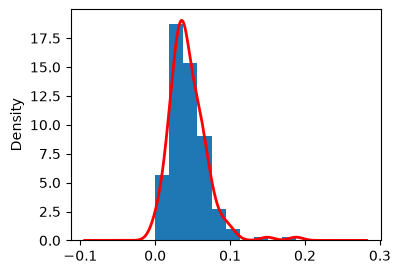

In [17]:
# plot histogram and density of undercount 
print(df['undercount'].describe())
plt.figure(figsize=(4, 3))
ax = df['undercount'].hist(density=True)
df['undercount'].plot.kde(ax=ax, color='red', linewidth=2)
plt.show()

<Axes: >

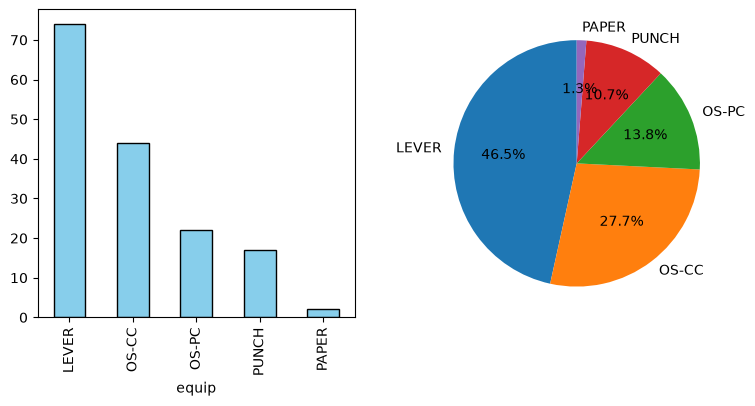

In [18]:
# bar plot and pie chart for categorical variable
counts = df['equip'].value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
counts.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
counts.plot(kind='pie', ax=axes[1], autopct='%1.1f%%', startangle=90)
# autopct='%1.1f%%: automatically calculate and display percentage for each slice of pie chart
# show percentage as float with 1 digit after decimal point 
# startangle=90: forces first slice to start at top center

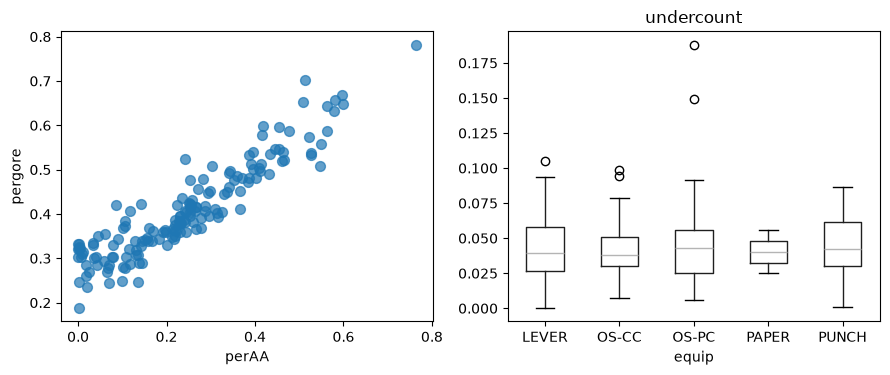

In [19]:
# relationship between two variables
df['pergore'] = df['gore'] / df['votes'] # proportion voting for Gore

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
df.plot.scatter(x='perAA', y='pergore', ax=axes[0], s=50, alpha=0.7)
df.boxplot(column='undercount', by='equip', ax=axes[1], grid=False)
plt.suptitle('') # Removes automatic, messy subtitle
plt.tight_layout()

# fig_path = os.path.join(fig_save_dir, "Gore_AA.pdf")
# fig.savefig(fig_path, bbox_inches="tight")  



In [20]:
# Create the contingency table
table = pd.crosstab(df['atlanta'], df['rural'])
print(table)

rural       rural  urban
atlanta                 
Atlanta         1     14
notAtlanta    116     28


In [21]:
# correlation between quantitative variables 
df[['perAA', 'ballots', 'undercount', 'pergore']].corr()

,perAA,ballots,undercount,pergore
perAA,1.000000,0.027732,0.229687,0.921652
ballots,0.027732,1.000000,-0.155172,0.095617
undercount,0.229687,-0.155172,1.000000,0.218765
pergore,0.921652,0.095617,0.218765,1.000000
